In [1]:
# This file is a jupytext-paired Python script export of
# `building_decision_models_solution.ipynb`. The canonical artifact for learners is
# the notebook (.ipynb); this script is provided for code review and `git diff`
# readability. Run `jupytext --sync` to keep the two in lockstep after edits.

# Structuring and Solving a Product Launch Decision (SOLUTION)

## Scenario

Trailmark Outdoor Co.'s VP of Product Strategy described three launch options for the
Ridge Runner trail shoe verbally — a spoken walkthrough, not a structured model. This
notebook turns that description into one.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATA_PATH = "../building-decision-models-starter/data/sporting_goods_sales.csv"

## 1. Derive state probabilities from market data

To estimate how likely each demand environment is, we benchmark against US sporting
goods retail sales data. `data/sporting_goods_sales.csv` contains monthly retail sales
figures for the sporting goods category (U.S. Census Bureau Monthly Retail Trade
Survey, NAICS 45111, public domain). We compute year-over-year growth rates and use
tertile binning to assign an empirical probability to each of three demand states.

In [3]:
sales = pd.read_csv(DATA_PATH)
sales.columns = ["date", "sales_m"]
sales["date"] = pd.to_datetime(sales["date"])
sales["yoy"] = sales["sales_m"].pct_change(12) * 100
sales = sales.dropna(subset=["yoy"])

t33, t67 = sales["yoy"].quantile([1/3, 2/3])

def classify(x):
    if x >= t67:  return "High"
    if x >= t33:  return "Base"
    return "Low"

sales["state"] = sales["yoy"].apply(classify)
counts = sales["state"].value_counts()
STATES = (counts / counts.sum()).reindex(["High", "Base", "Low"]).to_dict()

print(f"Demand states:")
print(f"  Low:  YoY growth < {t33:.1f}%")
print(f"  Base: YoY growth {t33:.1f}% to {t67:.1f}%")
print(f"  High: YoY growth >= {t67:.1f}%")
print()
print("State probabilities:")
for state, prob in STATES.items():
    print(f"  {state}: {prob:.3f}")

Demand states:
  Low:  YoY growth < 1.1%
  Base: YoY growth 1.1% to 3.1%
  High: YoY growth >= 3.1%

State probabilities:
  High: 0.343
  Base: 0.324
  Low: 0.333


By construction, tertile binning gives ~1/3 each. The threshold values come from
historical sporting goods market variation and anchor the probabilities to something
concrete rather than assumed.

## 2. Influence diagram — map the structure before writing any code

Before defining options or writing a payoff function, draw the dependency structure
of the decision. Three node types:

- **Rectangle** — Decision node: a variable *you* control
- **Oval** — Uncertainty node: an uncertain variable nature controls
- **Octagon** — Value node: the payoff that depends on both

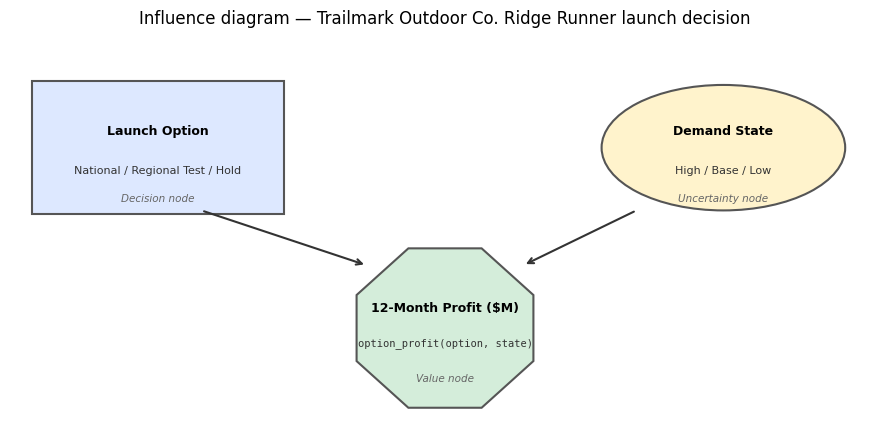

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.set_xlim(0, 10); ax.set_ylim(0, 5); ax.axis("off")
ax.set_title("Influence diagram — Trailmark Outdoor Co. Ridge Runner launch decision", pad=10)

# Decision node — rectangle (top-left)
ax.add_patch(mpatches.FancyBboxPatch(
    (0.3, 2.8), 2.8, 1.6, boxstyle="square,pad=0.05",
    fc="#dde8ff", ec="#555", lw=1.5, zorder=2))
ax.text(1.7, 3.8, "Launch Option", ha="center", va="center", fontsize=9, fontweight="bold")
ax.text(1.7, 3.3, "National / Regional Test / Hold", ha="center", va="center", fontsize=8, color="#333")
ax.text(1.7, 2.95, "Decision node", ha="center", va="center", fontsize=7.5, color="#666", style="italic")

# Uncertainty node — oval (top-right)
ax.add_patch(mpatches.Ellipse(
    (8.2, 3.6), 2.8, 1.6, fc="#fff3cc", ec="#555", lw=1.5, zorder=2))
ax.text(8.2, 3.8, "Demand State", ha="center", va="center", fontsize=9, fontweight="bold")
ax.text(8.2, 3.3, "High / Base / Low", ha="center", va="center", fontsize=8, color="#333")
ax.text(8.2, 2.95, "Uncertainty node", ha="center", va="center", fontsize=7.5, color="#666", style="italic")

# Value node — octagon (bottom-center)
import numpy as np
ax.add_patch(mpatches.RegularPolygon(
    (5.0, 1.3), numVertices=8, radius=1.1, orientation=np.pi/8,
    fc="#d4edda", ec="#555", lw=1.5, zorder=2))
ax.text(5.0, 1.55, "12-Month Profit ($M)", ha="center", va="center", fontsize=9, fontweight="bold")
ax.text(5.0, 1.1, "option_profit(option, state)", ha="center", va="center",
        fontsize=7.5, color="#333", family="monospace")
ax.text(5.0, 0.65, "Value node", ha="center", va="center", fontsize=7.5, color="#666", style="italic")

# Arrows: Decision → Profit, Demand State → Profit
ax.annotate("", xy=(4.1, 2.1), xytext=(2.2, 2.8),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#333"))
ax.annotate("", xy=(5.9, 2.1), xytext=(7.2, 2.8),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#333"))

plt.tight_layout()
plt.show()

There is no arrow between the Decision node and the Chance node. That encodes a
key modelling assumption: Trailmark Outdoor Co.'s launch choice does not change the
demand environment — whether the market turns out High, Base, or Low is independent
of which option they pick. This assumption might be wrong if a splashy National
Launch generates enough buzz to shift demand upward; in that case you would add the
arrow, and the model would need to capture that dependency explicitly.

The diagram is the design. Steps 3–8 build what the diagram describes.

## 3. Define the structure

Trailmark's VP of Product Strategy laid out three paths. **National Launch** commits
$700K to national marketing and broad retail distribution — high upside in a strong
demand environment, but unsold-inventory markdowns can flip revenue negative in a weak
one. **Regional Test Launch** is a more conservative $250K play in a handful of
priority markets, with a narrower range of outcomes in either direction. **Hold**
delays to next season: no spend, no upside, no downside.

In [5]:
OPTIONS = ["National Launch", "Regional Test Launch", "Hold"]

NATIONAL_LAUNCH_COST_M = 0.7
NATIONAL_LAUNCH_REV_M  = {"High": 13.0, "Base": 3.5, "Low": -3.5}

REGIONAL_TEST_COST_M   = 0.25
REGIONAL_TEST_REV_M    = {"High": 6.0,  "Base": 2.3, "Low":  0.7}

## 4. Implement `option_profit`

In [6]:
def option_profit(option: str, demand_state: str) -> float:
    """Net 12-month profit ($M) for a given option and demand state."""
    if option == "National Launch":
        return NATIONAL_LAUNCH_REV_M[demand_state] - NATIONAL_LAUNCH_COST_M
    if option == "Regional Test Launch":
        return REGIONAL_TEST_REV_M[demand_state] - REGIONAL_TEST_COST_M
    if option == "Hold":
        return 0.0
    raise ValueError(f"Unknown option: {option}")


assert option_profit("National Launch", "High")     == 12.3
assert round(option_profit("Regional Test Launch", "Low"), 2) == 0.45
assert option_profit("Hold", "Base")                ==  0.0

## 5. Build the payoff matrix

In [7]:
payoffs = pd.DataFrame(
    {state: {opt: option_profit(opt, state) for opt in OPTIONS}
     for state in STATES}
)
payoffs

,High,Base,Low
National Launch,12.30,2.80,-4.20
Regional Test Launch,5.75,2.05,0.45
Hold,0.00,0.00,0.00


## 6. Expected value per option

In [8]:
ev = (payoffs * pd.Series(STATES)).sum(axis=1)
ev.name = "EV ($M)"

print(f"EV-maximizing option: {ev.idxmax()}  (${ev.max():.2f}M)")
ev.round(2)

EV-maximizing option: National Launch  ($3.72M)


National Launch         3.72
Regional Test Launch    2.78
Hold                    0.00
Name: EV ($M), dtype: float64

## 7. Expected CRRA utility

A risk-neutral decision maker maximises expected value. A risk-averse one maximises
**expected utility** — a concave transformation of payoff that penalises losses more
heavily than equally-sized gains.

Here we use **CRRA (Constant Relative Risk Aversion)** utility with risk aversion
coefficient γ = 2, evaluated at total wealth rather than incremental profit:

`u(profit) = ((W + profit)^(1 − γ) − 1) / (1 − γ)`

The wealth baseline W = $20M represents Trailmark Outdoor Co.'s assumed existing
scale. Applying utility to (W + profit) rather than to raw profit keeps the function
well-defined even when incremental profit is negative, and means risk aversion is
measured relative to the firm's total position — not just the project in isolation.
With γ = 2, losses hurt more than equal-sized gains help.

In [9]:
GAMMA    = 2.0
WEALTH_M = 20.0   # Trailmark Outdoor Co.'s assumed baseline wealth ($M)

def utility(profit_m: float) -> float:
    """CRRA utility evaluated at (WEALTH_M + profit_m)."""
    x = WEALTH_M + profit_m
    if abs(GAMMA - 1.0) < 1e-9:
        return np.log(x)
    return (x ** (1 - GAMMA) - 1) / (1 - GAMMA)

eu = pd.Series(
    {opt: sum(STATES[s] * utility(option_profit(opt, s)) for s in STATES)
     for opt in OPTIONS}
)

ce_wealth = np.power(eu * (1.0 - GAMMA) + 1.0, 1.0 / (1.0 - GAMMA))
ce = ce_wealth - WEALTH_M

comparison = pd.DataFrame({
    "EV ($M)":        ev.round(2),
    "EV rank":        ev.rank(ascending=False).astype(int),
    "CE ($M)":        ce.round(2),
    "CE rank":        ce.rank(ascending=False).astype(int),
})
print(f"EV-maximizing option: {ev.idxmax()}  (EV = ${ev.max():.2f}M)")
print(f"CE-maximizing option: {ce.idxmax()}  (CE = ${ce.max():.2f}M)")
print()
comparison

EV-maximizing option: National Launch  (EV = $3.72M)
CE-maximizing option: Regional Test Launch  (CE = $2.57M)



,EV ($M),EV rank,CE ($M),CE rank
National Launch,3.72,1,1.78,2
Regional Test Launch,2.78,2,2.57,1
Hold,0.00,3,-0.00,3


## 8. Decision tree — backward induction (rollback)

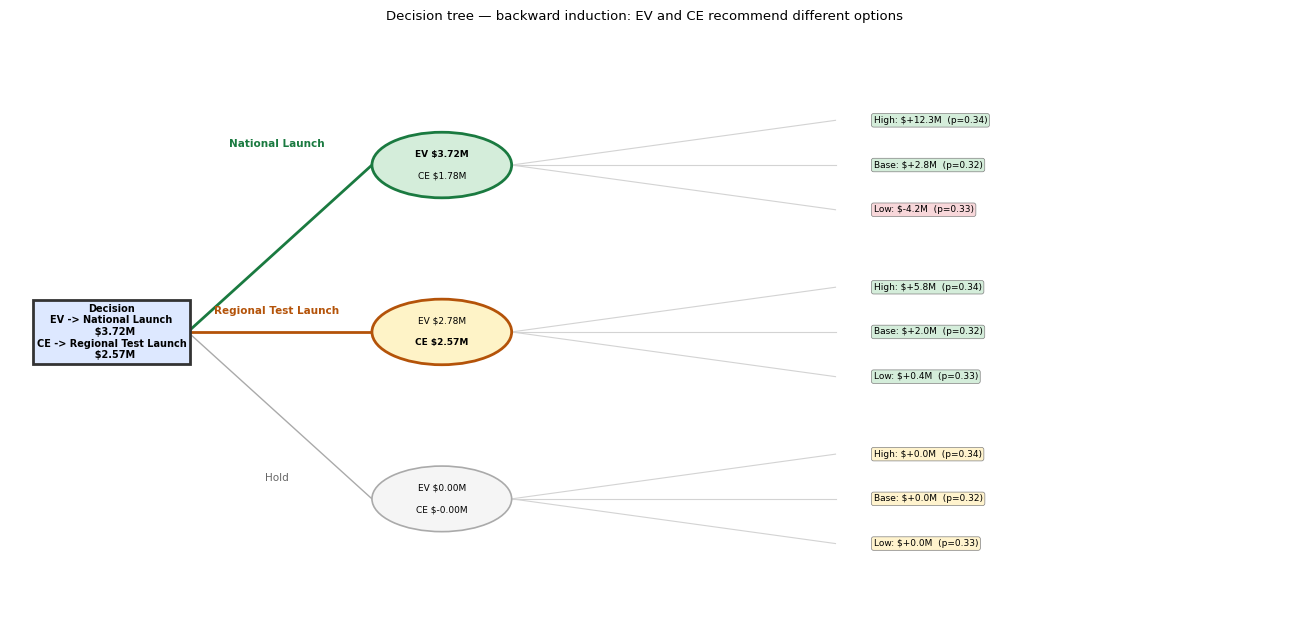

In [10]:
DEC_X, DEC_Y = 0.08, 0.50
CHANCE_X     = 0.34
LEAF_X       = 0.68
opt_ys       = [0.78, 0.50, 0.22]
state_labels = list(STATES.keys())

ev_best = ev.idxmax()   # National Launch
ce_best = ce.idxmax()   # Regional Test Launch

EV_COLOR  = "#1a7a40"   # green — EV-optimal branch
CE_COLOR  = "#b45309"   # amber — CE-optimal branch
NEU_COLOR = "#aaa"      # grey  — neither

def branch_color(opt):
    if opt == ev_best:   return EV_COLOR
    if opt == ce_best:   return CE_COLOR
    return NEU_COLOR

fig, ax = plt.subplots(figsize=(13, 6.5))
ax.axis("off")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(
    "Decision tree — backward induction: EV and CE recommend different options",
    fontsize=9.5, pad=10)

# ── Decision node ────────────────────────────────────────────────────────────
ax.text(DEC_X, DEC_Y,
        f"Decision\nEV -> {ev_best}\n  ${ev.max():.2f}M\nCE -> {ce_best}\n  ${ce.max():.2f}M",
        ha="center", va="center", fontsize=7, fontweight="bold",
        bbox=dict(boxstyle="square,pad=0.4", fc="#dde8ff", ec="#333", lw=2))

for opt, oy in zip(OPTIONS, opt_ys):
    col = branch_color(opt)
    lw  = 2.0 if col != NEU_COLOR else 1.0

    ev_here = ev[opt]
    ce_here = ce[opt]

    # Branch: decision node → chance node
    ax.plot([DEC_X + 0.060, CHANCE_X - 0.055], [DEC_Y, oy], color=col, lw=lw)
    ax.text((DEC_X + CHANCE_X) / 2, oy + 0.027, opt,
            ha="center", va="bottom", fontsize=7.5,
            color=col if col != NEU_COLOR else "#666",
            fontweight="bold" if col != NEU_COLOR else "normal")

    # Chance node circle — EV line bold if EV-optimal, CE line bold if CE-optimal
    node_fc = "#d4edda" if opt == ev_best else "#fef3c7" if opt == ce_best else "#f5f5f5"
    ax.add_patch(plt.Circle((CHANCE_X, oy), 0.055,
                             fc=node_fc, ec=col, lw=2 if col != NEU_COLOR else 1.2, zorder=3))
    ax.text(CHANCE_X, oy + 0.018, f"EV ${ev_here:.2f}M",
            ha="center", va="center", fontsize=6.5,
            fontweight="bold" if opt == ev_best else "normal")
    ax.text(CHANCE_X, oy - 0.018, f"CE ${ce_here:.2f}M",
            ha="center", va="center", fontsize=6.5,
            fontweight="bold" if opt == ce_best else "normal")

    # Leaves: chance node → state outcomes
    leaf_ys = np.linspace(oy + 0.075, oy - 0.075, len(state_labels))
    for s, ly in zip(state_labels, leaf_ys):
        profit = option_profit(opt, s)
        ax.plot([CHANCE_X + 0.055, LEAF_X - 0.03], [oy, ly], color="lightgrey", lw=0.8)
        leaf_fc = "#d4edda" if profit > 0 else "#f8d7da" if profit < 0 else "#fff3cd"
        ax.text(LEAF_X, ly, f"{s}: ${profit:+.1f}M  (p={STATES[s]:.2f})",
                va="center", fontsize=6.5,
                bbox=dict(boxstyle="round,pad=0.25", fc=leaf_fc, ec="grey", lw=0.5))

plt.tight_layout()
plt.show()

The influence diagram in step 2 showed the structure — three nodes, two arrows.
This tree enumerates all 9 paths through that structure and does something more:
it performs **backward induction**. Both EV and CE are rolled back at each chance node
(right to left), and the decision node takes the maximum under each criterion.

Here the two criteria disagree. A risk-neutral decision maker rolls back EV and picks
**National Launch** ($3.72M). A risk-averse one rolls back CE and picks
**Regional Test Launch** ($2.57M) — because National Launch's large downside in a
Low market gets penalised heavily by CRRA utility, reducing its certainty equivalent
well below its expected profit. The criterion you roll back determines the
recommendation you get.